## Guillespie Simulations for Power Law hypergraph


This notebook genereated the stocastic simualtion used to create the phase diagram of SIS process in a hypegraph with power law hyperdegree distribution and uncorrelted cross-order correlation used in figure 2 of the paper 'Unveiling the impact of cross-order hyperdegree correlations in contagion processes on hypergraphs'


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import xgi as xgi
import random as random
import time
import sys

In [4]:
sys.path.insert(1,'../Libraries/')

from Configurational_model_HO import* #one for the configurational mdoel and another
from Overlap_func import* #for calcualte overlap of higher order netowks
from HO_effective_degree import* #contains then necesaryt functions for effective hyperdegree

In [5]:
from datetime import datetime
start_time = datetime.now()


#N=500
N=1000
mu=1
k1=4.5
k2=2.66

lam1=1.2
lam2=2

beta1=lam1*mu/k1
beta2=lam2*mu/k2

iters=2
num_inf=20
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
    
init_infec_num=[0]
T=40



N=1000

gam1=2.5
gam2=2.25

gam1str=int(str(gam1).replace('.', ''))
gam2str=int(str(gam2).replace('.', ''))


pairs= np.loadtxt(f'../data/higherorder_networkstructures/powlaw_pairs_N{N}_gam1{gam1str}_gam2{gam2str}.txt',dtype=float).astype(int)
triples=np.loadtxt(f'../data/higherorder_networkstructures/powlaw_triples_N{N}_gam1{gam1str}_gam2{gam2str}.txt',dtype=float).astype(int)


init_infec=np.random.choice(range(0,N-1),size=init_infec_num)

#I, times_sim, I_links, I_hyperedges, times_links, times_hyperedges=SIS_gillespie_HO(N, beta1, beta2, mu, edges=pairs, triangles=triples, init_infec=init_infec, t_max=T)
times_runs, I_runs, S_runs=SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=pairs, triangles=triples, fixed_init=fixed_init, t_max=T, check_interval=2000, variance_threshold=1e-4)

all_sim=[]
I=I_runs[0]



end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))


ValueError: could not convert string '8.090000000000000000e+02' to int64 at row 0, column 1.

(-0.5, 40.0)

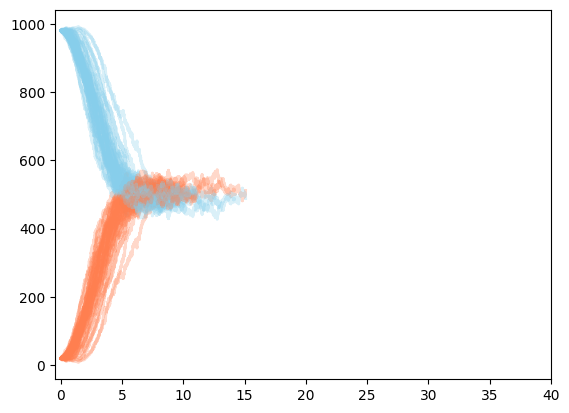

In [12]:
# plt.title(r'Regular $k_1=4, k_2=2$')
#plt.plot(times_model,I_model)
N=1000
k1=8
k2=4

for j in range (50):
    #data_sim=np.loadtxt(f'poisson_simulation/sim_N{N}_k1{k1}_k2{k2}_{j}.txt')
    t,S_,I_=times_runs[j],S_runs[j],I_runs[j]
    plt.plot(t,I_,lw=2,color='coral', alpha=0.3)
    plt.plot(t,S_,lw=2,color='skyblue', alpha=0.3)

plt.xlim((-0.5,40))


In [ ]:
from datetime import datetime
start_time = datetime.now()

lambdas=np.linspace(0.001,2,50)
lambdas = lambdas[::3]


#N=500
#N=500
N=1000
mu=1
k1=4.5
k2=2.66

lam2=2.5

beta1=lam1*mu/k1
beta2=lam2*mu/k2

iters=100
num_inf=20
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
    
init_infec_num=[0]
T=80


N=1000

gam1=2.5
gam2=2.25

gam1str=int(str(gam1).replace('.', ''))
gam2str=int(str(gam2).replace('.', ''))

pairs= np.loadtxt(f'../data/higherorder_networkstructures/powlaw_pairs_N{N}_gam1{gam1str}_gam2{gam2str}.txt',dtype=float).astype(int)
triples=np.loadtxt(f'../data/higherorder_networkstructures/powlaw_triples_N{N}_gam1{gam1str}_gam2{gam2str}.txt',dtype=float).astype(int)

init_infec=np.random.choice(range(0,N-1),size=init_infec_num)

prevalences=[]
I_steady_states1=[]
for lam in lambdas:
    beta1=lam*mu/k1
#I, times_sim, I_links, I_hyperedges, times_links, times_hyperedges=SIS_gillespie_HO(N, beta1, beta2, mu, edges=pairs, triangles=triples, init_infec=init_infec, t_max=T)
    times_runs, I_runs, S_runs=SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=pairs, triangles=triples, fixed_init=fixed_init, t_max=T, check_interval=1000, variance_threshold=1e-8)
    
    all_sim=[]
    epidemic_size=[]
    for i in range (len(I_runs)):
        I=I_runs[i]
        times=times_runs[i]
        #minio_helper.save_file(f'Simulation_Poisson_HO_alpha0/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim_arr, obj_type='csv' )
        if np.mean(I[-100:])>30:
            epidemic_size.append(np.mean(I[-100:]))
        else:
            epidemic_size.append(0)
        #np.savetxt(f'poisson_simulation/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim)

    
    I_steady_states1.append(epidemic_size)
    print(f'Lambda=  {lam}, Epidemic_size = {np.mean(epidemic_size)}, final time {times[-1]} ')

    prevalences.append(np.mean(epidemic_size))

end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))




/tmp/ipykernel_1326632/707493743.py:39: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  pairs= np.loadtxt(f'../PowerLaw_structures/powlaw_pairs_uncorrIK_N{N}_gam1{gam1str}_gam2{gam2str}.txt',dtype=int)
/tmp/ipykernel_1326632/707493743.py:40: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing 

Lambda=  0.001, Epidemic_size = 0.0, final time 2.8402352935782114 
Lambda=  0.12338775510204081, Epidemic_size = 0.0, final time 2.815043945936341 
Lambda=  0.24577551020408162, Epidemic_size = 0.0, final time 3.4287512669726867 
Lambda=  0.3681632653061224, Epidemic_size = 0.0, final time 2.751681439331167 
Lambda=  0.49055102040816323, Epidemic_size = 173.02919999999997, final time 2.372884201366143 
Lambda=  0.612938775510204, Epidemic_size = 372.60140000000007, final time 80.00006046103293 
Lambda=  0.7353265306122448, Epidemic_size = 444.212, final time 80.00112199466083 
Lambda=  0.8577142857142857, Epidemic_size = 484.06280000000004, final time 80.0002983288539 
Lambda=  0.9801020408163265, Epidemic_size = 511.24160000000006, final time 80.00021383890568 
Lambda=  1.1024897959183673, Epidemic_size = 545.197, final time 80.00106632199474 
Lambda=  1.224877551020408, Epidemic_size = 564.9158000000001, final time 80.0000591666607 
Lambda=  1.3472653061224489, Epidemic_size = 587.7

In [7]:
np.savetxt('../data/Phase_diagram/pow_I_steady_state1.txt',I_steady_states1)

In [7]:
print(I_steady_states1)

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
from datetime import datetime
start_time = datetime.now()

lambdas=np.linspace(0.001,2,50)
lambdas = lambdas[::3]


#N=500
#N=500
N=1000
mu=1
k1=4.5
k2=2.66

lam2=2.5

beta1=lam1*mu/k1
beta2=lam2*mu/k2

iters=100
num_inf=800
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
    
init_infec_num=[0]
T=30


N=1000

gam1=2.5
gam2=2.25

gam1str=int(str(gam1).replace('.', ''))
gam2str=int(str(gam2).replace('.', ''))

pairs= np.loadtxt(f'../data/higherorder_networkstructures/powlaw_pairs_N{N}_gam1{gam1str}_gam2{gam2str}.txt',dtype=float).astype(int)
triples=np.loadtxt(f'../data/higherorder_networkstructures/powlaw_triples_N{N}_gam1{gam1str}_gam2{gam2str}.txt',dtype=float).astype(int)


init_infec=np.random.choice(range(0,N-1),size=init_infec_num)

prevalences=[]
I_steady_states2=[]
for lam in lambdas:
    beta1=lam*mu/k1
#I, times_sim, I_links, I_hyperedges, times_links, times_hyperedges=SIS_gillespie_HO(N, beta1, beta2, mu, edges=pairs, triangles=triples, init_infec=init_infec, t_max=T)
    times_runs, I_runs, S_runs=SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=pairs, triangles=triples, fixed_init=fixed_init, t_max=T, check_interval=1000, variance_threshold=1e-8)
    
    all_sim=[]
    epidemic_size=[]
    for i in range (len(I_runs)):
        I=I_runs[i]
        times=times_runs[i]
        #minio_helper.save_file(f'Simulation_Poisson_HO_alpha0/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim_arr, obj_type='csv' )
        if np.mean(I[-100:])>30:
            epidemic_size.append(np.mean(I[-100:]))
        else:
            epidemic_size.append(0)
        #np.savetxt(f'poisson_simulation/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim)

    
    I_steady_states2.append(epidemic_size)
    print(f'Lambda=  {lam}, Epidemic_size = {np.mean(epidemic_size)}, final time {times[-1]} ')

    prevalences.append(np.mean(epidemic_size))

end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))



/tmp/ipykernel_1326632/3934339034.py:39: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  pairs= np.loadtxt(f'../PowerLaw_structures/powlaw_pairs_uncorrIK_N{N}_gam1{gam1str}_gam2{gam2str}.txt',dtype=int)
/tmp/ipykernel_1326632/3934339034.py:40: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsin

Lambda=  0.001, Epidemic_size = 135.2946, final time 30.010150940275704 
Lambda=  0.12338775510204081, Epidemic_size = 225.107, final time 30.001607098150686 
Lambda=  0.24577551020408162, Epidemic_size = 293.4764, final time 30.00043780887061 
Lambda=  0.3681632653061224, Epidemic_size = 346.6322, final time 30.00221750590662 
Lambda=  0.49055102040816323, Epidemic_size = 390.9606, final time 30.000048136720142 
Lambda=  0.612938775510204, Epidemic_size = 431.80940000000004, final time 30.000414398969 
Lambda=  0.7353265306122448, Epidemic_size = 467.33459999999997, final time 30.000141090053173 
Lambda=  0.8577142857142857, Epidemic_size = 496.3021999999999, final time 30.00238719108648 
Lambda=  0.9801020408163265, Epidemic_size = 521.4630000000001, final time 30.000829762017002 
Lambda=  1.1024897959183673, Epidemic_size = 545.6307999999999, final time 30.000041398743964 
Lambda=  1.224877551020408, Epidemic_size = 565.5187999999999, final time 30.000412469140944 
Lambda=  1.347265

In [8]:
print(I_steady_states2)

[[125.58, 214.84, 153.8, 126.32, 185.68, 194.6, 50.54, 144.52, 123.14, 192.66, 183.4, 170.98, 111.48, 0, 161.42, 189.48, 145.34, 155.92, 180.72, 82.7, 169.42, 0, 143.76, 159.8, 220.64, 138.94, 104.78, 121.72, 154.88, 163.78, 96.68, 196.14, 0, 0, 142.76, 137.62, 113.4, 164.54, 136.84, 0, 162.26, 112.94, 167.54, 157.76, 160.56, 171.64, 156.8, 0, 136.54, 161.8, 212.04, 0, 136.9, 182.44, 203.46, 103.92, 168.14, 163.28, 120.66, 130.78, 148.5, 157.62, 144.74, 183.04, 173.6, 101.44, 155.72, 0, 174.08, 0, 209.92, 171.5, 133.78, 185.78, 104.84, 117.9, 213.54, 0, 188.28, 0, 167.5, 207.54, 158.88, 178.22, 84.66, 118.9, 185.24, 0, 221.32, 144.86, 87.82, 78.76, 141.82, 160.88, 146.8, 176.3, 131.7, 146.96, 200.38, 158.36], [236.92, 201.7, 233.32, 220.22, 215.82, 236.04, 238.18, 237.04, 176.28, 188.42, 212.88, 227.08, 239.2, 183.08, 196.68, 257.16, 227.26, 256.78, 229.54, 198.06, 249.54, 270.02, 224.88, 234.44, 219.0, 227.72, 262.02, 242.32, 230.86, 266.04, 235.06, 217.56, 228.54, 252.6, 210.04, 185.

In [13]:
np.savetxt('../data/Phase_diagram/pow_I_steady_state2.txt',I_steady_states2)

In [10]:
print(len(I_steady_states2))

17
